In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
import os
print(os.getcwd())

c:\Users\admin\Desktop\Projects\news-sentiment-analysis\notebooks


In [33]:
print(os.listdir())

['eda.ipynb', 'README.md', 'task2_stock_analysis.ipynb', '__init__.py']


In [34]:
import os

print(os.listdir(".."))

['.git', '.gitattributes', '.github', '.gitignore', 'data', 'notebooks', 'README.md', 'requirements.txt', 'scripts', 'src', 'tests', 'venv']


In [35]:
print(os.listdir("../data"))

['raw']


# AAPL Stock Analysis

In [36]:
print(os.listdir("../data/raw"))

['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv', 'raw_analyst_ratings.csv']


In [37]:
import pandas as pd
import glob

files = glob.glob("../data/raw/*.csv")

stock_files = [f for f in files if "analyst" not in f]

df_list = []

for file in stock_files:
    print("Loading stock:", file)
    temp_df = pd.read_csv(file)
    temp_df["ticker"] = file.split("\\")[-1].replace(".csv", "")
    df_list.append(temp_df)

stock_df = pd.concat(df_list, ignore_index=True)

Loading stock: ../data/raw\AAPL.csv


Loading stock: ../data/raw\AMZN.csv
Loading stock: ../data/raw\GOOG.csv
Loading stock: ../data/raw\META.csv
Loading stock: ../data/raw\NVDA.csv


In [38]:
analyst_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

analyst_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [ ]:
df_aapl.columns = df_aapl.columns.str.strip().str.title()

In [ ]:
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_aapl = df_aapl.sort_values('Date')

In [ ]:
import talib

df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

In [ ]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['EMA_20'], label='EMA 20')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df['RSI'])
plt.axhline(70, color='red')
plt.axhline(30, color='green')
plt.title("RSI")
plt.show()

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df['MACD'], label='MACD')
plt.plot(df['MACD_signal'], label='Signal')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/raw/AAPL.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [ ]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [ ]:
df = df.dropna()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [ ]:
df.set_index('Date', inplace=True)

In [ ]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [ ]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

In [ ]:
import matplotlib.pyplot as plt

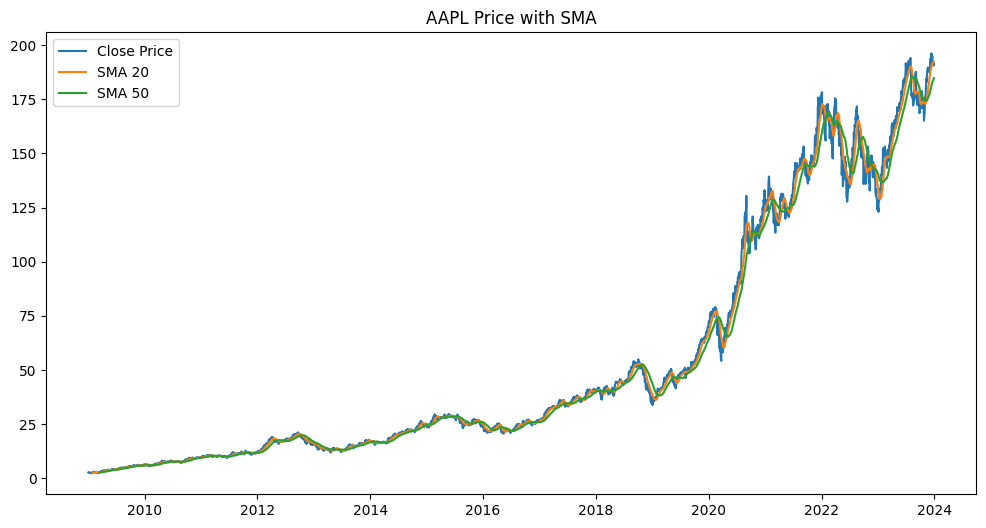

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')

plt.title("AAPL Price with SMA")
plt.legend()
plt.show()

In [ ]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

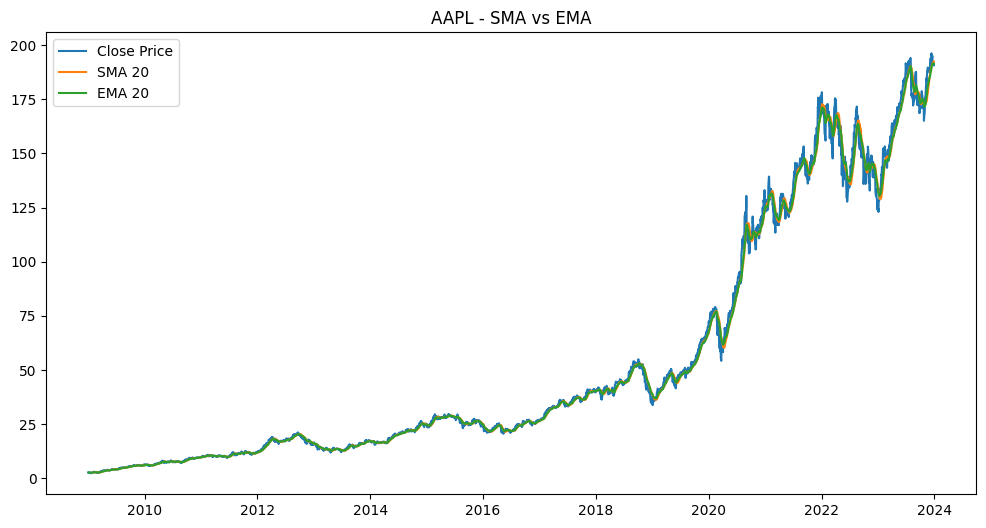

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['EMA_20'], label='EMA 20')

plt.title("AAPL - SMA vs EMA")
plt.legend()
plt.show()

In [ ]:
delta = df['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

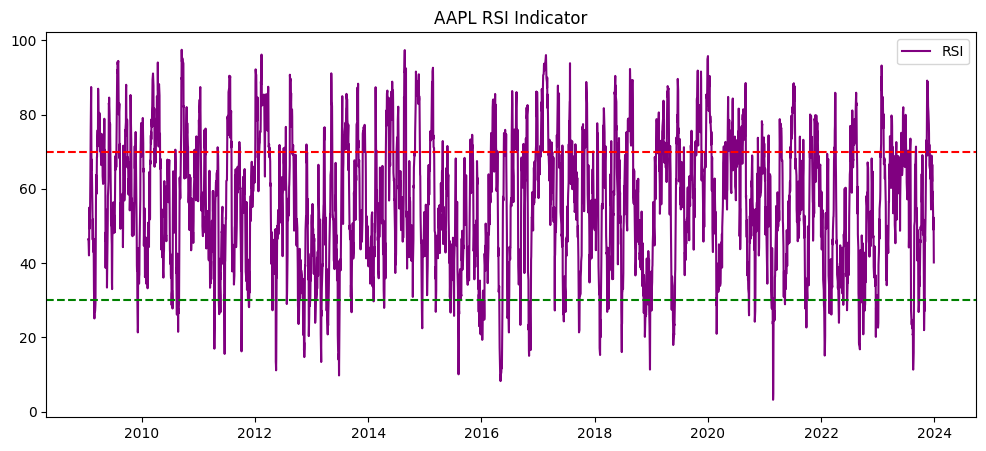

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', color='red')
plt.axhline(30, linestyle='--', color='green')

plt.title("AAPL RSI Indicator")
plt.legend()
plt.show()

In [ ]:
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

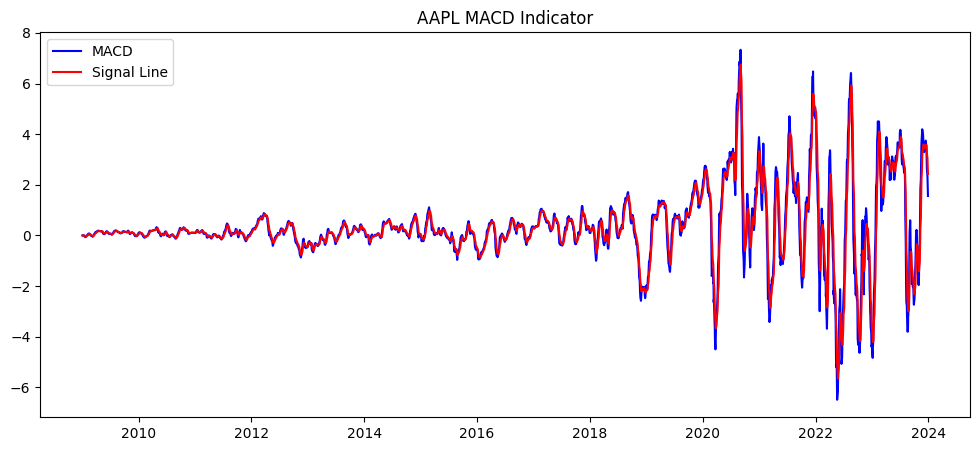

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['Signal_Line'], label='Signal Line', color='red')

plt.title("AAPL MACD Indicator")
plt.legend()
plt.show()

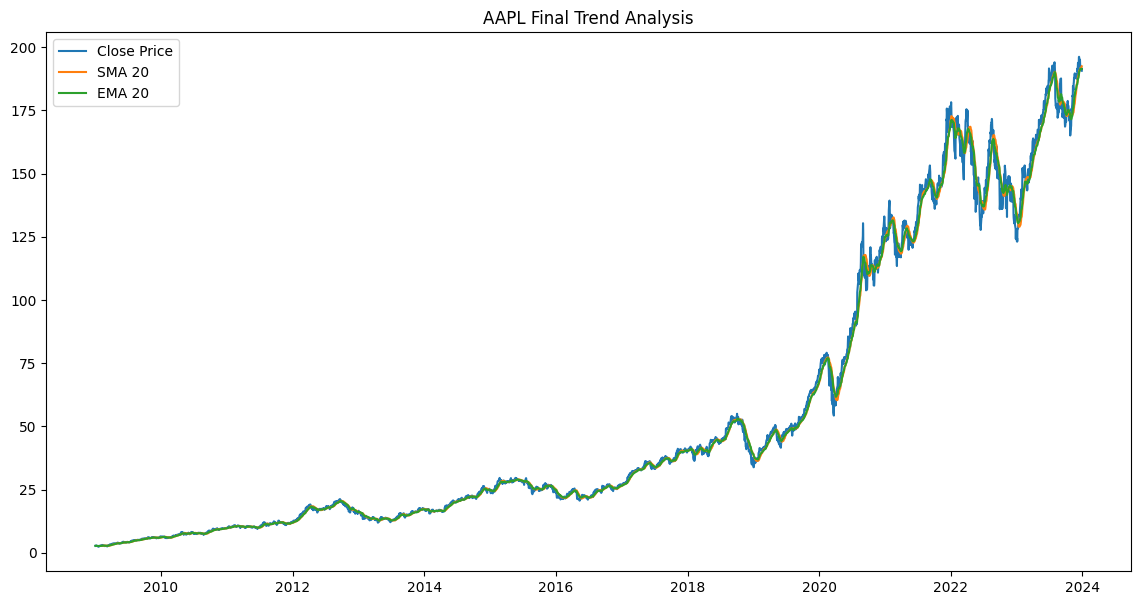

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['EMA_20'], label='EMA 20')

plt.title("AAPL Final Trend Analysis")
plt.legend()
plt.show()

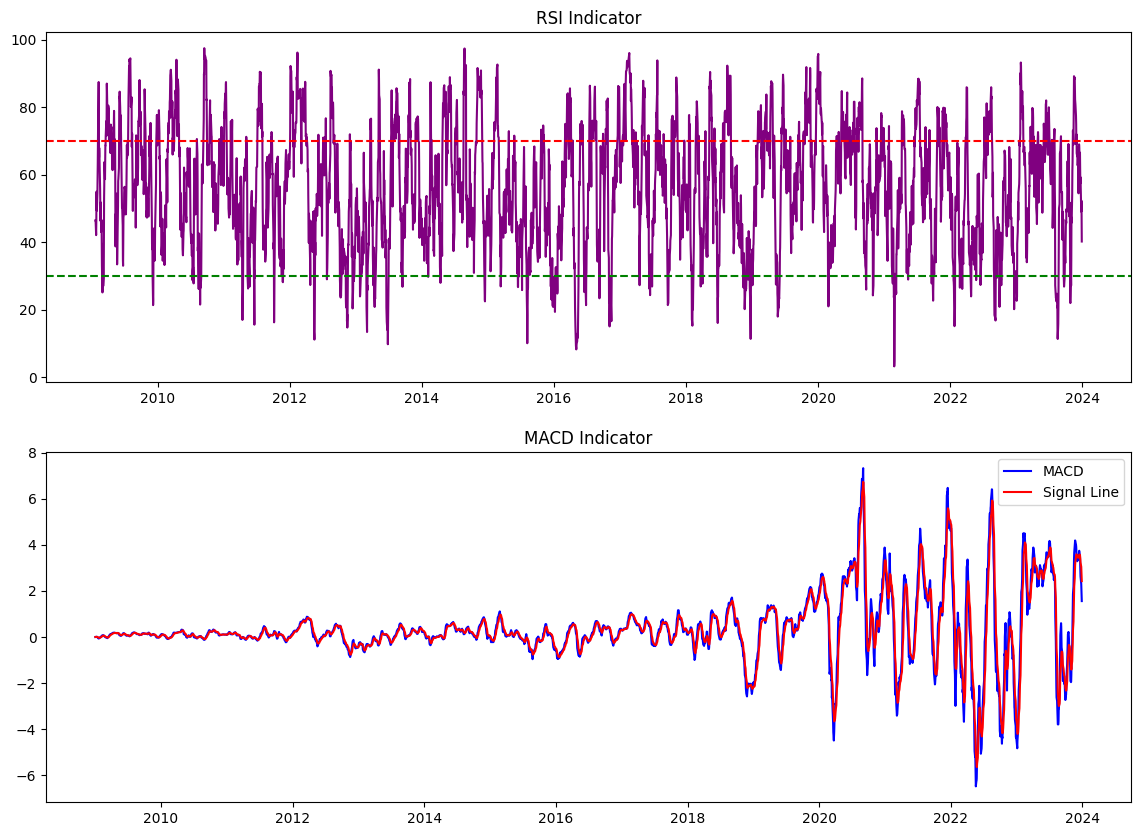

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(14,10))

# RSI
ax[0].plot(df['RSI'], label='RSI', color='purple')
ax[0].axhline(70, linestyle='--', color='red')
ax[0].axhline(30, linestyle='--', color='green')
ax[0].set_title("RSI Indicator")

# MACD
ax[1].plot(df['MACD'], label='MACD', color='blue')
ax[1].plot(df['Signal_Line'], label='Signal Line', color='red')
ax[1].set_title("MACD Indicator")

plt.legend()
plt.show()

In [ ]:
print("AAPL analysis completed successfully")

AAPL analysis completed successfully


# AMZN Stock Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_amzn = pd.read_csv("../data/raw/AMZN.csv")
df_amzn.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


In [ ]:
df_amzn.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [ ]:
df_amzn.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [ ]:
df_amzn = df_amzn.dropna()

In [ ]:
df_amzn['Date'] = pd.to_datetime(df_amzn['Date'])
df_amzn = df_amzn.sort_values('Date')

In [ ]:
df_amzn.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


In [ ]:
df_amzn.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [ ]:
df_amzn['SMA_20'] = df_amzn['Close'].rolling(window=20).mean()
df_amzn['SMA_50'] = df_amzn['Close'].rolling(window=50).mean()

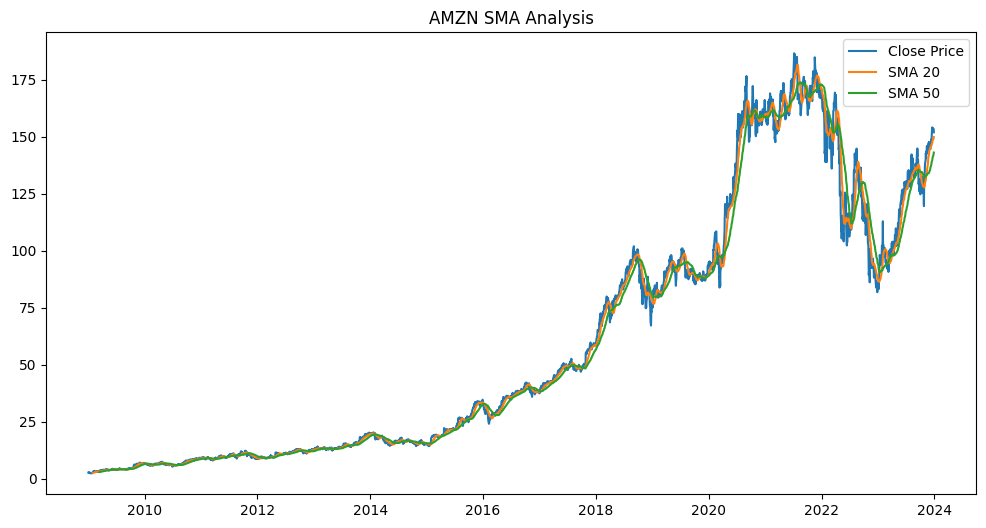

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_amzn['Date'], df_amzn['Close'], label='Close Price')
plt.plot(df_amzn['Date'], df_amzn['SMA_20'], label='SMA 20')
plt.plot(df_amzn['Date'], df_amzn['SMA_50'], label='SMA 50')

plt.legend()
plt.title("AMZN SMA Analysis")
plt.show()

In [ ]:
df_amzn['EMA_20'] = df_amzn['Close'].ewm(span=20, adjust=False).mean()
df_amzn['EMA_50'] = df_amzn['Close'].ewm(span=50, adjust=False).mean()

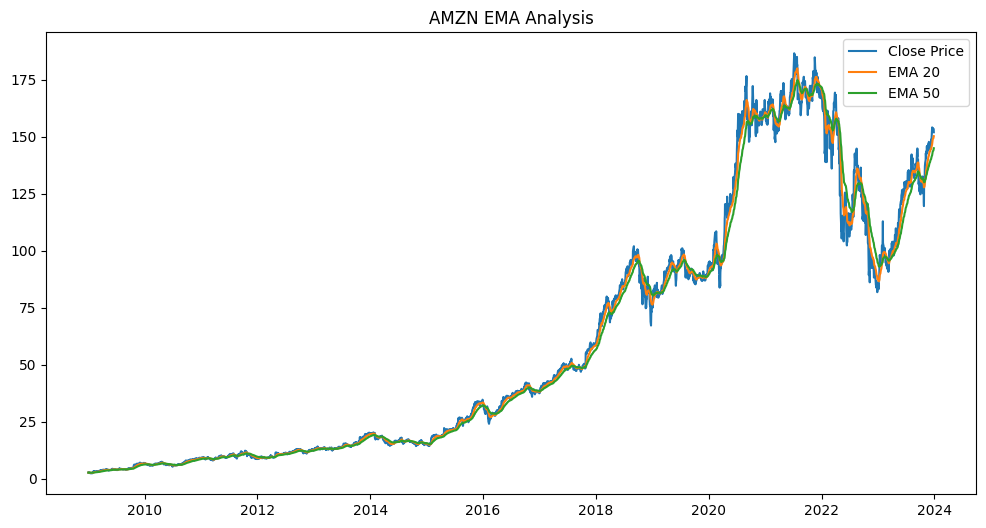

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_amzn['Date'], df_amzn['Close'], label='Close Price')
plt.plot(df_amzn['Date'], df_amzn['EMA_20'], label='EMA 20')
plt.plot(df_amzn['Date'], df_amzn['EMA_50'], label='EMA 50')

plt.legend()
plt.title("AMZN EMA Analysis")
plt.show()

In [ ]:
delta = df_amzn['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
df_amzn['RSI'] = 100 - (100 / (1 + rs))

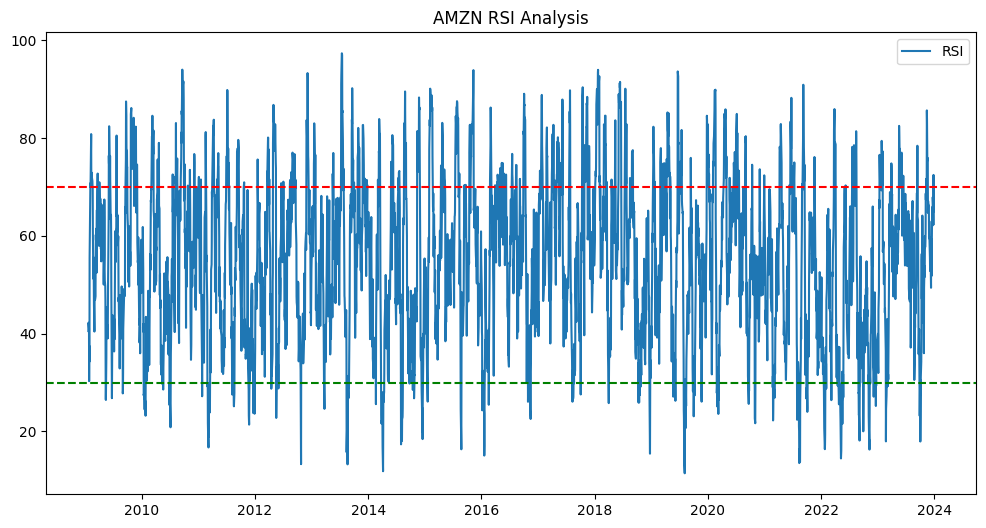

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_amzn['Date'], df_amzn['RSI'], label='RSI')

plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

plt.title("AMZN RSI Analysis")
plt.legend()
plt.show()

In [ ]:
ema_12 = df_amzn['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df_amzn['Close'].ewm(span=26, adjust=False).mean()

df_amzn['MACD'] = ema_12 - ema_26
df_amzn['Signal'] = df_amzn['MACD'].ewm(span=9, adjust=False).mean()

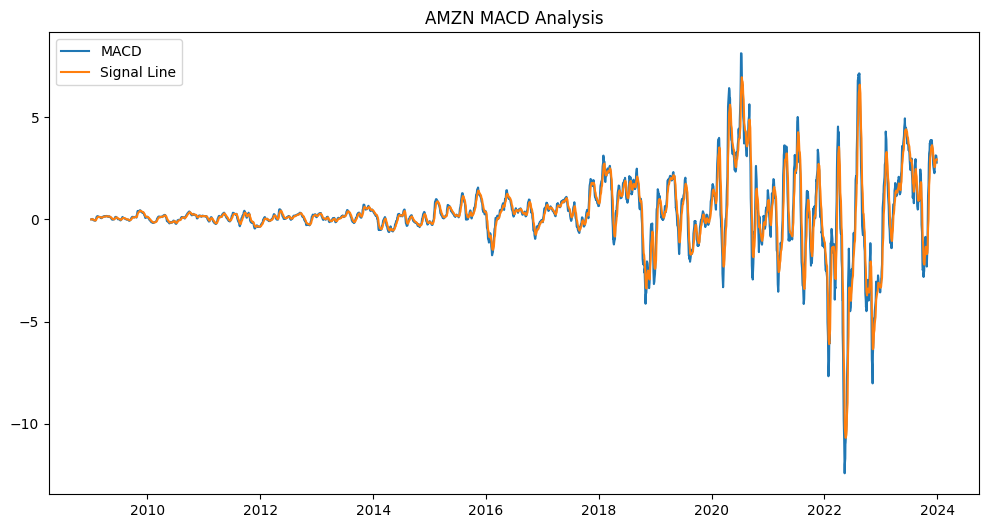

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_amzn['Date'], df_amzn['MACD'], label='MACD')
plt.plot(df_amzn['Date'], df_amzn['Signal'], label='Signal Line')

plt.legend()
plt.title("AMZN MACD Analysis")
plt.show()

# AAPL vs AMZN Comparison

This visualization compares the closing stock prices of AAPL and AMZN over time.

In [41]:
df_aapl = pd.read_csv("../data/raw/AAPL.csv")

df_aapl.columns = df_aapl.columns.str.strip().str.title()

df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])

df_aapl = df_aapl.sort_values('Date')

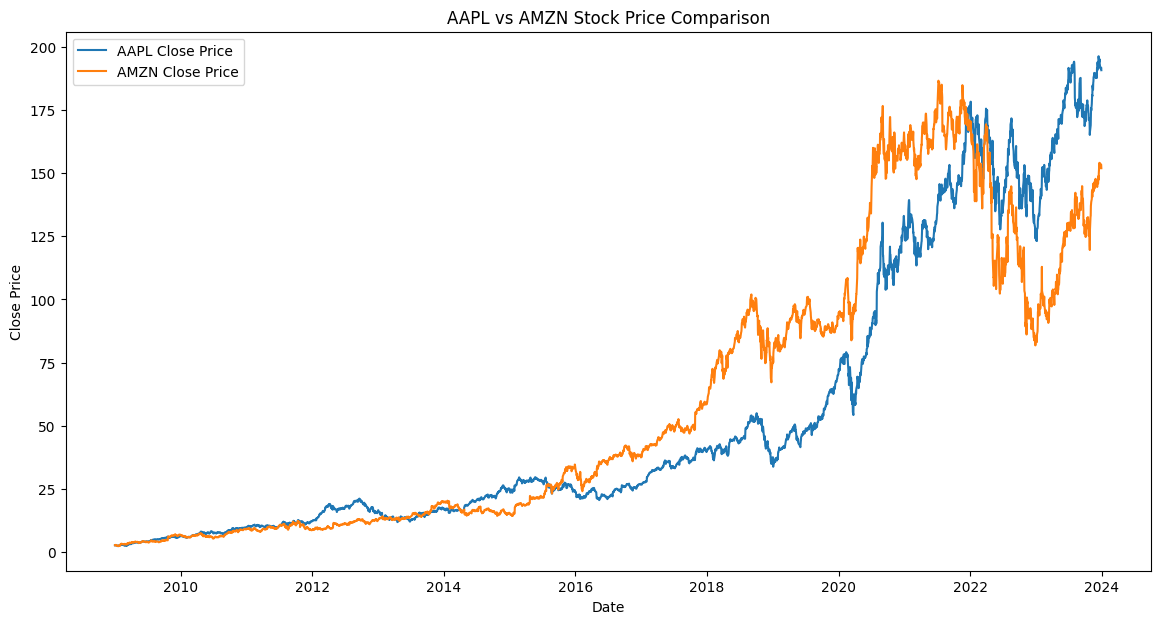

In [42]:
plt.figure(figsize=(14,7))

plt.plot(df_aapl['Date'], df_aapl['Close'], label='AAPL Close Price')
plt.plot(df_amzn['Date'], df_amzn['Close'], label='AMZN Close Price')

plt.title("AAPL vs AMZN Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.legend()
plt.show()